<a href="https://colab.research.google.com/github/lilian662/Portafolio/blob/main/proeyctofinalsimulaccionII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analizando los precios de audifonos de liverpol mediante cadenas de markov y simulacion de Monte Carlo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# leemos las bases

normal = pd.read_excel("audifonos_y_manos_libres_liverpool_limpiobueno (1).xlsx")
black = pd.read_excel("audifonos_y_manos_libres_liverpool_blackfriday (1).xlsx")

print(normal.head())
print(black.head())

   Categoría       Marca                                        Descripción  \
0  Audífonos     SAMSUNG  Audífonos in-ear Galaxy Buds3 FE inalámbricos ...   
1  Audífonos      XIAOMI  Audífonos True Wireless Redmi Buds 6 Lite inal...   
2  Audífonos        SONY                      Audífonos On-Ear inalámbricos   
3  Audífonos  SWISS CODE  Audífonos In-Ear Seed Pro Anc inalámbricos con...   
4  Audífonos        SONY              Audífonos In-Ear Wi-C100 inalámbricos   

  Precio sin descuento Precio con descuento  \
0            $2,499.00            $2,199.00   
1                  NaN              $399.00   
2            $1,319.00              $749.00   
3              $665.00              $399.00   
4              $799.00              $499.00   

                                        URL Producto  \
0  https://www.liverpool.com.mx/tienda/pdp/aud%C3...   
1  https://www.liverpool.com.mx/tienda/pdp/aud%C3...   
2  https://www.liverpool.com.mx/tienda/pdp/aud%C3...   
3  https://www.liv

In [ ]:

# Limpiamos los precios

def limpiar_precio(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.replace("$", "")
    x = x.replace(",", "")
    x = x.strip()
    try:
        return float(x)
    except:
        return np.nan

for df in [normal, black]:
    df["Precio sin descuento"] = df["Precio sin descuento"].apply(limpiar_precio)
    df["Precio con descuento"] = df["Precio con descuento"].apply(limpiar_precio)

normal.head()

,Categoría,Marca,Descripción,Precio sin descuento,Precio con descuento,URL Producto,URL Imagen
0,Audífonos,SAMSUNG,Audífonos in-ear Galaxy Buds3 FE inalámbricos ...,2499.0,2199.0,https://www.liverpool.com.mx/tienda/pdp/aud%C3...,https://ss632.liverpool.com.mx/sm/1184125214.jpg
1,Audífonos,XIAOMI,Audífonos True Wireless Redmi Buds 6 Lite inal...,NaN,399.0,https://www.liverpool.com.mx/tienda/pdp/aud%C3...,https://ss632.liverpool.com.mx/sm/1165812448.jpg
2,Audífonos,SONY,Audífonos On-Ear inalámbricos,1319.0,749.0,https://www.liverpool.com.mx/tienda/pdp/aud%C3...,https://ss630.liverpool.com.mx/sm/1178743631.jpg
3,Audífonos,SWISS CODE,Audífonos In-Ear Seed Pro Anc inalámbricos con...,665.0,399.0,https://www.liverpool.com.mx/tienda/pdp/aud%C3...,https://ss630.liverpool.com.mx/sm/1149667772.jpg
4,Audífonos,SONY,Audífonos In-Ear Wi-C100 inalámbricos,799.0,499.0,https://www.liverpool.com.mx/tienda/pdp/aud%C3...,https://ss630.liverpool.com.mx/sm/1121501194.jpg


In [ ]:

# calculamos los descuentos

def calcular_descuento(df):
    df = df.copy()
    df["Descuento"] = (
        (df["Precio sin descuento"] - df["Precio con descuento"])
        / df["Precio sin descuento"]
    )
    df["Descuento"] = df["Descuento"].fillna(0)
    df["Descuento"] = df["Descuento"].clip(lower=0)
    return df

normal = calcular_descuento(normal)
black = calcular_descuento(black)

normal[["Marca", "Descripción", "Precio sin descuento", "Precio con descuento", "Descuento"]].head()

,Marca,Descripción,Precio sin descuento,Precio con descuento,Descuento
0,SAMSUNG,Audífonos in-ear Galaxy Buds3 FE inalámbricos ...,2499.0,2199.0,0.120048
1,XIAOMI,Audífonos True Wireless Redmi Buds 6 Lite inal...,NaN,399.0,0.000000
2,SONY,Audífonos On-Ear inalámbricos,1319.0,749.0,0.432146
3,SWISS CODE,Audífonos In-Ear Seed Pro Anc inalámbricos con...,665.0,399.0,0.400000
4,SONY,Audífonos In-Ear Wi-C100 inalámbricos,799.0,499.0,0.375469


In [ ]:

# utilizamos cadenas de Markov

def estado_descuento(d):
    if d == 0:
        return "E0: sin descuento"
    elif d <= 0.20:
        return "E1: 1%-20%"
    elif d <= 0.40:
        return "E2: 21%-40%"
    elif d <= 0.60:
        return "E3: 41%-60%"
    else:
        return "E4: más de 60%"

normal["Estado normal"] = normal["Descuento"].apply(estado_descuento)
black["Estado black friday"] = black["Descuento"].apply(estado_descuento)

In [ ]:

# unimos las dos bases

normal = normal.drop_duplicates(subset=["URL Producto"])
black = black.drop_duplicates(subset=["URL Producto"])

datos = pd.merge(
    normal,
    black,
    on=["URL Producto"],
    suffixes=("_normal", "_bf")
)

print("Productos comparables:", len(datos))

print(datos.columns)



Productos comparables: 1723
Index(['Categoría_normal', 'Marca_normal', 'Descripción_normal',
       'Precio sin descuento_normal', 'Precio con descuento_normal',
       'URL Producto', 'URL Imagen_normal', 'Descuento_normal',
       'Estado normal', 'Categoría_bf', 'Marca_bf', 'Descripción_bf',
       'Precio sin descuento_bf', 'Precio con descuento_bf', 'URL Imagen_bf',
       'Descuento_bf', 'Estado black friday'],
      dtype='object')


In [ ]:

# MATRIZ DE TRANSICIÓN
#clasificamos los estados


estados = [
    "E0: sin descuento",
    "E1: 1%-20%",
    "E2: 21%-40%",
    "E3: 41%-60%",
    "E4: más de 60%"
]

conteos = pd.crosstab(
    datos["Estado normal"],
    datos["Estado black friday"]
).reindex(index=estados, columns=estados, fill_value=0)

matriz_transicion = conteos.div(conteos.sum(axis=1), axis=0).fillna(0)

print("Matriz de conteos:")
display(conteos)

print("Matriz de transición:")
display(matriz_transicion)
print(matriz_transicion)

Matriz de conteos:


Estado black friday,E0: sin descuento,E1: 1%-20%,E2: 21%-40%,E3: 41%-60%,E4: más de 60%
Estado normal,,,,,
E0: sin descuento,413,56,177,17,0
E1: 1%-20%,2,247,39,3,1
E2: 21%-40%,8,8,491,36,1
E3: 41%-60%,10,8,4,167,4
E4: más de 60%,0,0,1,0,30


Matriz de transición:


Estado black friday,E0: sin descuento,E1: 1%-20%,E2: 21%-40%,E3: 41%-60%,E4: más de 60%
Estado normal,,,,,
E0: sin descuento,0.622926,0.084465,0.266968,0.025641,0.000000
E1: 1%-20%,0.006849,0.845890,0.133562,0.010274,0.003425
E2: 21%-40%,0.014706,0.014706,0.902574,0.066176,0.001838
E3: 41%-60%,0.051813,0.041451,0.020725,0.865285,0.020725
E4: más de 60%,0.000000,0.000000,0.032258,0.000000,0.967742


Estado black friday  E0: sin descuento  E1: 1%-20%  E2: 21%-40%  E3: 41%-60%  \
Estado normal                                                                  
E0: sin descuento             0.622926    0.084465     0.266968     0.025641   
E1: 1%-20%                    0.006849    0.845890     0.133562     0.010274   
E2: 21%-40%                   0.014706    0.014706     0.902574     0.066176   
E3: 41%-60%                   0.051813    0.041451     0.020725     0.865285   
E4: más de 60%                0.000000    0.000000     0.032258     0.000000   

Estado black friday  E4: más de 60%  
Estado normal                        
E0: sin descuento          0.000000  
E1: 1%-20%                 0.003425  
E2: 21%-40%                0.001838  
E3: 41%-60%                0.020725  
E4: más de 60%             0.967742  


In [ ]:

# Simulando con monte carlo


N = 100000

# Probabilidad inicial: cómo están distribuidos los productos antes del Black Friday
prob_inicial = datos["Estado normal"].value_counts(normalize=True).reindex(estados, fill_value=0)

sim_estados_iniciales = np.random.choice(
    estados,
    size=N,
    p=prob_inicial.values
)

sim_estados_finales = []

for e in sim_estados_iniciales:
    probs = matriz_transicion.loc[e].values

    # Si una fila queda en ceros, se queda en el mismo estado
    if probs.sum() == 0:
        sim_estados_finales.append(e)
    else:
        sim_estados_finales.append(np.random.choice(estados, p=probs))

sim = pd.DataFrame({
    "Estado inicial": sim_estados_iniciales,
    "Estado final": sim_estados_finales
})

sim.head()

,Estado inicial,Estado final
0,E0: sin descuento,E0: sin descuento
1,E2: 21%-40%,E2: 21%-40%
2,E1: 1%-20%,E1: 1%-20%
3,E2: 21%-40%,E2: 21%-40%
4,E3: 41%-60%,E1: 1%-20%


In [ ]:
# resultados de la simulación

resultados = sim["Estado final"].value_counts(normalize=True).reindex(estados, fill_value=0)

print("Distribución simulada de estados en Black Friday:")
display(resultados)

prob_descuento_alto = resultados["E3: 41%-60%"] + resultados["E4: más de 60%"]

print("Probabilidad simulada de obtener descuento mayor al 40%:")
print(prob_descuento_alto)

Distribución simulada de estados en Black Friday:


,proportion
Estado final,
E0: sin descuento,0.24994
E1: 1%-20%,0.18587
E2: 21%-40%,0.41342
E3: 41%-60%,0.12995
E4: más de 60%,0.02082


Probabilidad simulada de obtener descuento mayor al 40%:
0.15077000000000002


In [ ]:
# calculando un intervalo de confianza con el 95% de confianza

p = prob_descuento_alto
error = 1.96 * np.sqrt((p * (1 - p)) / N)

li = p - error
ls = p + error

print("Intervalo de confianza al 95% para descuento mayor al 40%:")
print(li, ls)

Intervalo de confianza al 95% para descuento mayor al 40%:
0.14855218047462074 0.1529878195253793


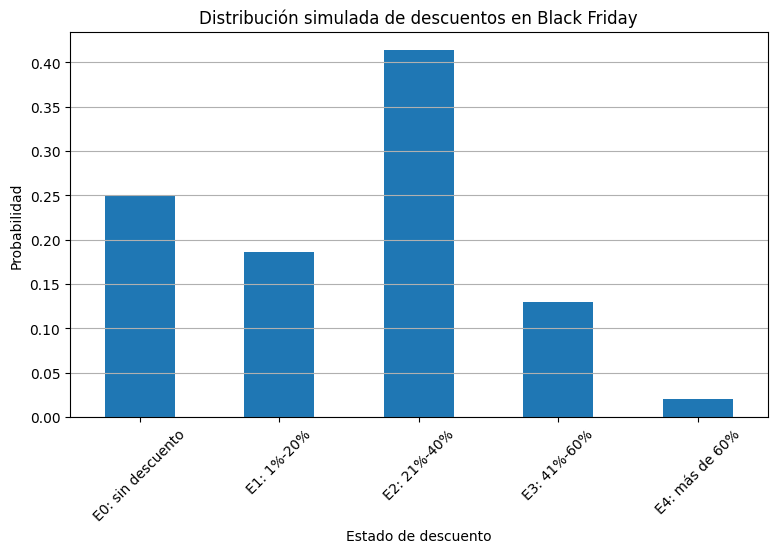

In [ ]:

plt.figure(figsize=(9,5))
resultados.plot(kind="bar")
plt.title("Distribución simulada de descuentos en Black Friday")
plt.ylabel("Probabilidad")
plt.xlabel("Estado de descuento")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [ ]:
datos["Ahorro"] = (
    datos["Precio con descuento_normal"]
    - datos["Precio con descuento_bf"]
)

print("Ahorro promedio:")
print(datos["Ahorro"].mean())

print("Ahorro máximo:")
print(datos["Ahorro"].max())

print("Ahorro mínimo:")
print(datos["Ahorro"].min())

Ahorro promedio:
75.72827713059472
Ahorro máximo:
3513.0
Ahorro mínimo:
-4414.0


In [ ]:
print("Productos sin cambio:")
print((datos["Ahorro"] == 0).sum())

print("Productos con ahorro:")
print((datos["Ahorro"] > 0).sum())

print("Productos más caros en Black Friday:")
print((datos["Ahorro"] < 0).sum())

Productos sin cambio:
1088
Productos con ahorro:
436
Productos más caros en Black Friday:
107


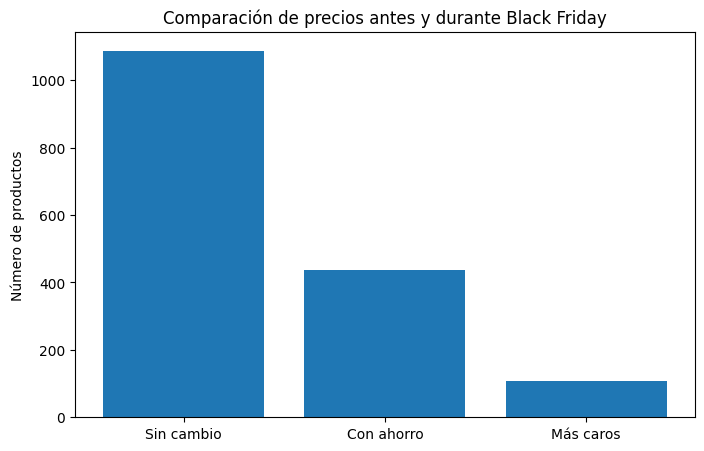

In [ ]:
sin_cambio = (datos["Ahorro"] == 0).sum()
con_ahorro = (datos["Ahorro"] > 0).sum()
mas_caros = (datos["Ahorro"] < 0).sum()

plt.figure(figsize=(8,5))

plt.bar(
    ["Sin cambio", "Con ahorro", "Más caros"],
    [sin_cambio, con_ahorro, mas_caros]
)

plt.title("Comparación de precios antes y durante Black Friday")
plt.ylabel("Número de productos")

plt.show()

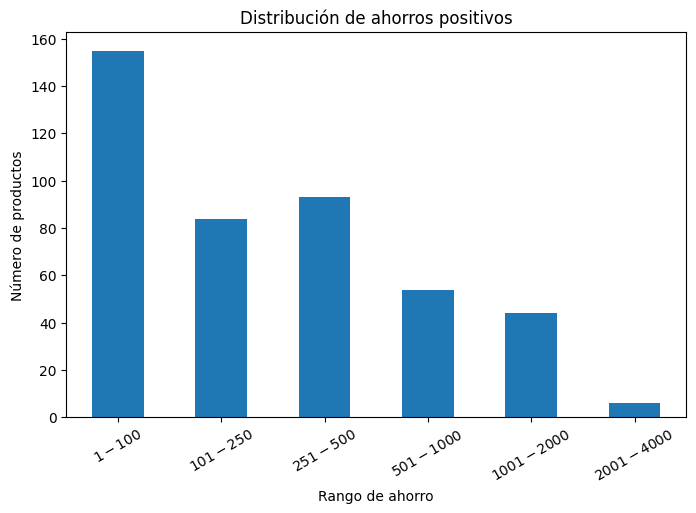

In [ ]:
rangos = pd.cut(
    datos["Ahorro"],
    bins=[0,100,250,500,1000,2000,4000],
    labels=[
        "$1-$100",
        "$101-$250",
        "$251-$500",
        "$501-$1000",
        "$1001-$2000",
        "$2001-$4000"
    ]
)

conteos = rangos.value_counts().sort_index()

plt.figure(figsize=(8,5))
conteos.plot(kind="bar")

plt.title("Distribución de ahorros positivos")
plt.xlabel("Rango de ahorro")
plt.ylabel("Número de productos")

plt.xticks(rotation=30)
plt.show()

In [ ]:
top10 = datos.nlargest(10, "Ahorro")

top10[[
    "Marca_normal",
    "Descripción_normal",
    "Ahorro"
]]

,Marca_normal,Descripción_normal,Ahorro
1318,AUDIOTECHNICA,Audífonos Over-Ear Ath-M50Xsts alámbricos,3513.00
1034,SENNHEISER,Audífonos Over-Ear Momentum Wireless 4 inalámb...,2909.40
1239,AUDIOTECHNICA,Audífonos Over-Ear inalámbricos,2455.00
1395,SENNHEISER,Audífonos True Wireless Momentum True Wireless...,2078.40
1176,SENNHEISER,Audífonos In-Ear Momentum Sport inalámbricos c...,2069.40
1459,RAZER,Audífonos gamer Over-Ear Razer Barracuda X Cro...,2029.38
563,BOWERS & WILKINS,Audífonos Over-Ear Px8 inalámbricos con cancel...,1999.80
652,BOWERS & WILKINS,Audífonos Over-Ear Px8-Tan inalámbricos con ca...,1999.80
640,FERRARI SCUDERIA,Audífonos Over-Ear P200 alámbricos,1990.00
1701,MARSHALL,Audífonos True Wireless inalámbricos con cance...,1919.20


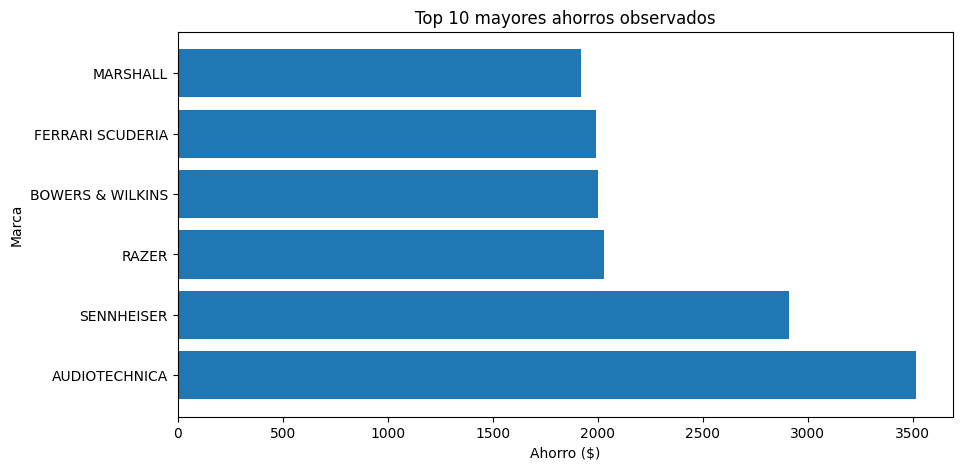

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(
    top10["Marca_normal"],
    top10["Ahorro"]
)

plt.title("Top 10 mayores ahorros observados")
plt.xlabel("Ahorro ($)")
plt.ylabel("Marca")

plt.show()

#Conclusión.

El análisis de los precios de audífonos y manos libres de Liverpool permitió observar de manera clara cómo cambian los descuentos antes y durante el Black Friday. A través de la limpieza de datos, el cálculo de descuentos y la clasificación por estados, fue posible construir una cadena de Markov que muestra la transición de los productos entre distintos niveles de descuento. Esto ayudó a identificar qué tan probable es que un producto pase de tener poco o ningún descuento a presentar una promoción más atractiva durante el evento.

Además, la simulación de Monte Carlo permitió estimar con mayor seguridad la distribución esperada de descuentos en Black Friday, especialmente la probabilidad de encontrar descuentos mayores al 40%. Este enfoque resulta útil porque no solo se basa en los datos observados, sino que también permite simular muchos escenarios posibles para obtener una estimación más estable y confiable. De esta forma, el proyecto demuestra que las herramientas probabilísticas pueden aplicarse de manera práctica al análisis de precios reales.

Finalmente, al comparar los precios antes y durante Black Friday, se pudo identificar que no todos los productos representan una verdadera oportunidad de ahorro, ya que algunos mantienen su precio e incluso otros pueden aumentar. Por ello, este análisis permite concluir que el Black Friday sí puede ofrecer descuentos importantes, pero no de forma generalizada. Es recomendable comparar precios previamente y no asumir que todos los productos en promoción son necesariamente más baratos. En general, el uso de cadenas de Markov y simulación de Monte Carlo permitió obtener una visión más completa del comportamiento de los descuentos y tomar decisiones de compra mejor fundamentadas